In [1]:
# ==========================================
# 1. IMPORTING REQUIRED LIBRARIES
# ==========================================
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Modules from scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set visualization style
sns.set_theme(style="darkgrid", palette="muted")
print("All necessary libraries imported successfully!")

All necessary libraries imported successfully!


In [2]:
# ==========================================
# 2. LOAD STOCK DATA (yfinance API)
# ==========================================
print("Fetching AAPL data from Yahoo Finance...")

# Download Apple stock data
# start : Start date of the historical data
# end   : End date of the historical data
stock_data = yf.download("AAPL", start="2020-01-01", end="2024-01-01")

print("Data fetched successfully!\n")
print("--- FIRST 5 ROWS ---")
display(stock_data.head())

print(f"\nDataset Shape: {stock_data.shape[0]} Rows, {stock_data.shape[1]} Columns")

Fetching AAPL data from Yahoo Finance...


/tmp/ipykernel_53879/2350505995.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download("AAPL", start="2020-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed

Data fetched successfully!

--- FIRST 5 ROWS ---


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.400528,72.460791,71.156689,71.409793,135480400
2020-01-03,71.696648,72.455966,71.472469,71.629153,146322800
2020-01-06,72.267937,72.306506,70.568510,70.819208,118387200
2020-01-07,71.928047,72.533087,71.708687,72.277571,108872000
2020-01-08,73.085121,73.386438,71.631567,71.631567,132079200



Dataset Shape: 1006 Rows, 5 Columns


--- CHECKING FOR MISSING VALUES ---
Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

--- DATASET INFO ---
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1006 entries, 2020-01-02 to 2023-12-29
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, AAPL)   1006 non-null   float64
 1   (High, AAPL)    1006 non-null   float64
 2   (Low, AAPL)     1006 non-null   float64
 3   (Open, AAPL)    1006 non-null   float64
 4   (Volume, AAPL)  1006 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 47.2 KB


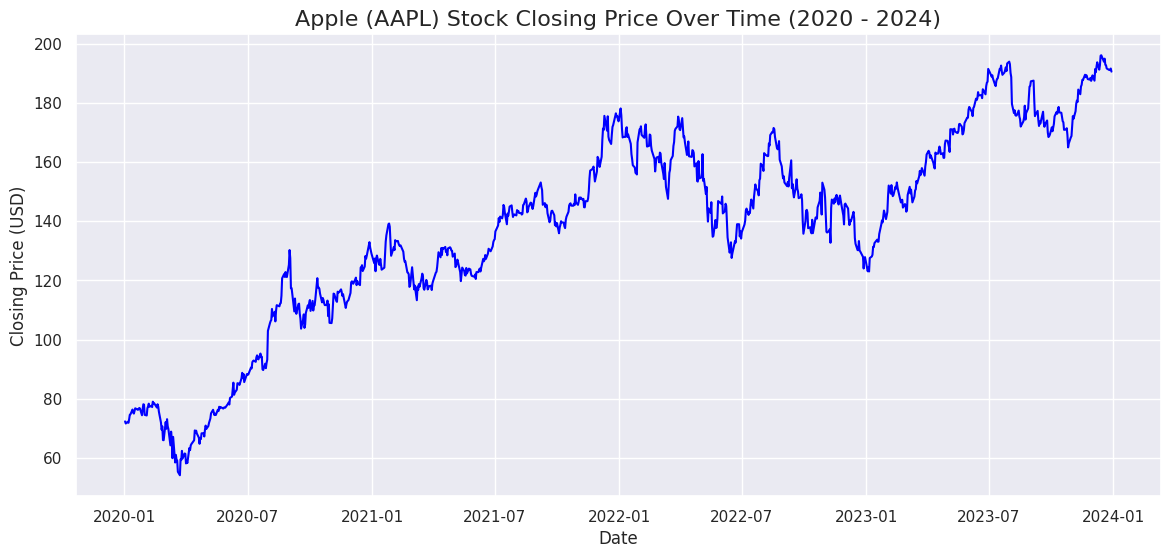

In [3]:
# ==========================================
# 3. DATA INSPECTION & EXPLORATION
# ==========================================
print("--- CHECKING FOR MISSING VALUES ---")
print(stock_data.isnull().sum())

print("\n--- DATASET INFO ---")
stock_data.info()

# Visualize the historical closing price
plt.figure(figsize=(14, 6))
# Using the Date index for the X-axis and 'Close' for the Y-axis
plt.plot(stock_data.index, stock_data['Close'], color='blue', linewidth=1.5)
plt.title("Apple (AAPL) Stock Closing Price Over Time (2020 - 2024)", fontsize=16)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Closing Price (USD)", fontsize=12)
plt.grid(True)
plt.show()

In [4]:
# ==========================================
# 4. PREPROCESSING & FEATURE ENGINEERING
# ==========================================
# Create the Target Variable ('Next_Close')
# .shift(-1) moves the data up by 1 row.
# So, row 0's 'Next_Close' will contain row 1's 'Close' value.
stock_data['Next_Close'] = stock_data['Close'].shift(-1)

# Because we shifted the data up, the very last row will now have a NaN (missing) value
# since there is no "next day" available in the dataset to pull from.
# We must drop this NaN row so it doesn't break our ML model.
stock_data.dropna(inplace=True)

print("Target variable 'Next_Close' created successfully.")
print("Last row containing NaN has been dropped.")
print(f"New Dataset Shape: {stock_data.shape}")

# Define Features (X) and Target (Y)
# We use today's Open, High, Low, and Volume to predict tomorrow's Close.
X = stock_data[['Open', 'High', 'Low', 'Volume']]
Y = stock_data['Next_Close']

print("\nFeatures (X):", X.columns.tolist())
print("Target (Y)  : Next_Close")

Target variable 'Next_Close' created successfully.
Last row containing NaN has been dropped.
New Dataset Shape: (1005, 6)

Features (X): [('Open', 'AAPL'), ('High', 'AAPL'), ('Low', 'AAPL'), ('Volume', 'AAPL')]
Target (Y)  : Next_Close


In [5]:
# ==========================================
# 5. TRAIN-TEST SPLIT & SCALING
# ==========================================

# Split data: 80% Training, 20% Testing
# shuffle=False : Extremely important! Keeps the dates in chronological order.
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, shuffle=False)

print("--- DATA SPLIT SUMMARY ---")
print(f"Training Data: {X_train.shape[0]} days (Past Data)")
print(f"Testing Data : {X_test.shape[0]} days (Future Data to predict)")

# Feature Scaling using StandardScaler
# Brings Open, High, Low, and Volume to a similar scale (mean=0, variance=1)
scaler = StandardScaler()

# Fit on training data, then transform both train and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeatures have been successfully scaled!")

--- DATA SPLIT SUMMARY ---
Training Data: 804 days (Past Data)
Testing Data : 201 days (Future Data to predict)

Features have been successfully scaled!


In [6]:
# ==========================================
# 6. LINEAR REGRESSION MODEL
# ==========================================
# Create and Train the model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, Y_train)

# Make Predictions on the Test set
lr_predictions = lr_model.predict(X_test_scaled)

# Evaluate the model
print("--- LINEAR REGRESSION METRICS ---")
lr_mae = mean_absolute_error(Y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(Y_test, lr_predictions))
lr_r2 = r2_score(Y_test, lr_predictions)

print(f"Mean Absolute Error (MAE): ${lr_mae:.2f} (Average error in dollars)")
print(f"Root Mean Squared Error (RMSE): ${lr_rmse:.2f}")
print(f"R2 Score: {lr_r2:.4f} (Closer to 1.0 is better)")

--- LINEAR REGRESSION METRICS ---
Mean Absolute Error (MAE): $1.65 (Average error in dollars)
Root Mean Squared Error (RMSE): $2.22
R2 Score: 0.9579 (Closer to 1.0 is better)


In [7]:
# ==========================================
# 7. RANDOM FOREST MODEL
# ==========================================
# Create and Train the model (using 100 trees)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, Y_train)

# Make Predictions on the Test set
rf_predictions = rf_model.predict(X_test_scaled)

# Evaluate the model
print("--- RANDOM FOREST METRICS ---")
rf_mae = mean_absolute_error(Y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(Y_test, rf_predictions))
rf_r2 = r2_score(Y_test, rf_predictions)

print(f"Mean Absolute Error (MAE): ${rf_mae:.2f} (Average error in dollars)")
print(f"Root Mean Squared Error (RMSE): ${rf_rmse:.2f}")
print(f"R2 Score: {rf_r2:.4f} (Closer to 1.0 is better)")

--- RANDOM FOREST METRICS ---
Mean Absolute Error (MAE): $7.52 (Average error in dollars)
Root Mean Squared Error (RMSE): $10.37
R2 Score: 0.0839 (Closer to 1.0 is better)


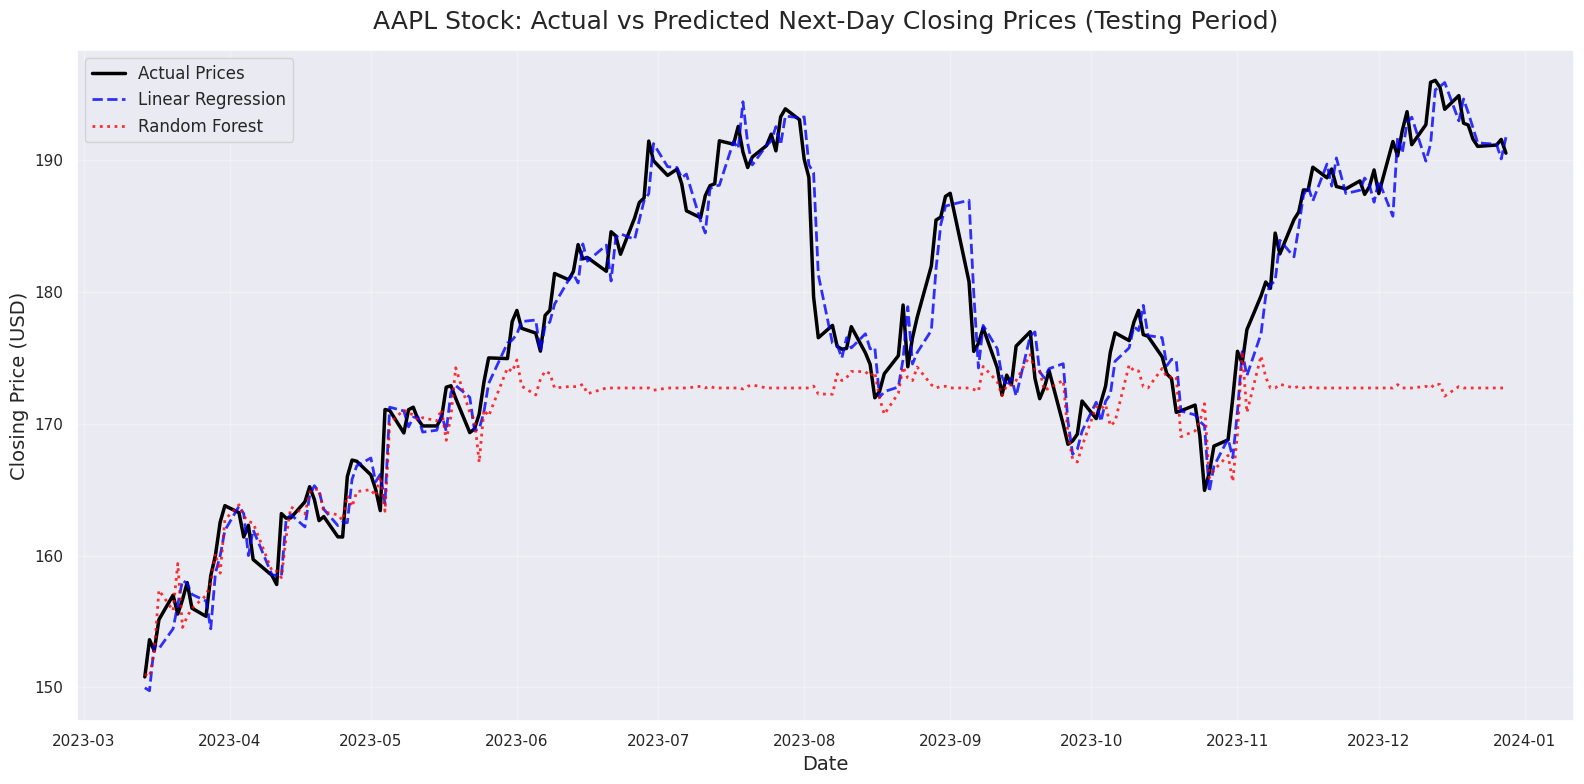

In [8]:
# ==========================================
# 8. PLOT: ACTUAL VS PREDICTED (FINAL REQUIREMENT)
# ==========================================
plt.figure(figsize=(16, 8))

# Plot the Actual Next-Day Closing Prices (Testing Data dates)
plt.plot(Y_test.index, Y_test.values, color='black', label='Actual Prices', linewidth=2.5)

# Plot Linear Regression Predictions
plt.plot(Y_test.index, lr_predictions, color='blue', label='Linear Regression', linestyle='dashed', alpha=0.8, linewidth=2)

# Plot Random Forest Predictions
plt.plot(Y_test.index, rf_predictions, color='red', label='Random Forest', linestyle='dotted', alpha=0.8, linewidth=2)

# Graph Formatting
plt.title("AAPL Stock: Actual vs Predicted Next-Day Closing Prices (Testing Period)", fontsize=18, pad=15)
plt.xlabel("Date", fontsize=14)
plt.ylabel("Closing Price (USD)", fontsize=14)
plt.legend(loc="upper left", fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()